# Lab 1: Time Series Characterization

Student: Lopatenko George (334771) \
Course: Machine Learning for Time Series (TSML)

## Scope
- Load 3 open univariate series (length 500–1000): periodic energy, cardiogram, Brownian finance
- For each: seasonal decomposition, FFT, ACF, Hurst (+ Hausdorff), Lyapunov (+ KS entropy), permutation entropy
- Preliminary conclusion on predictability


## 0. Setup


In [10]:
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
LAB_DIR = Path.cwd()
if not (LAB_DIR / "requirements.txt").exists():
    for candidate in [LAB_DIR / "tsml" / "lab-1", LAB_DIR.parent / "tsml" / "lab-1", Path("/content")]:
        if (candidate / "requirements.txt").exists():
            LAB_DIR = candidate
            break

REQ_FILE = LAB_DIR / "requirements.txt"
if IN_COLAB and REQ_FILE.exists():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(REQ_FILE)])

LAB_DIR, IN_COLAB


(PosixPath('/Users/lopatenko/Desktop/itmo/itmo-ml-2025/tsml/lab-1'), False)

In [11]:
import json
import math
import random
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf

import antropy as ant
import nolds

warnings.filterwarnings("ignore")

SEED = 42
MIN_LEN, MAX_LEN = 500, 1000
FIG_WIDTH, FIG_SCALE = 1400, 3

pio.templates.default = "plotly_white"
pio.renderers.default = "notebook_connected+png"


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed()

FIGURES_DIR = LAB_DIR / "figures"
DATA_DIR = LAB_DIR / "data"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

{
    "lab_dir": str(LAB_DIR),
    "figures": str(FIGURES_DIR),
    "data": str(DATA_DIR),
}


{'lab_dir': '/Users/lopatenko/Desktop/itmo/itmo-ml-2025/tsml/lab-1',
 'figures': '/Users/lopatenko/Desktop/itmo/itmo-ml-2025/tsml/lab-1/figures',
 'data': '/Users/lopatenko/Desktop/itmo/itmo-ml-2025/tsml/lab-1/data'}

## 1. Data loaders

Three open univariate series (length 500–1000):
- **EU hourly electricity load** (Darts `energy_dataset`) – clear daily/weekly periods
- **ECG** (TensorFlow ECG anomaly CSV) – cardiogram, concatenated consecutive beats
- **SPY** adjusted close (Yahoo chart API) – Brownian-like finance walk


In [12]:
@dataclass(frozen=True)
class SeriesBundle:
    name: str
    domain: str
    kind: str
    source: str
    values: np.ndarray
    index: Optional[pd.Index] = None


ENERGY_URL = "https://raw.githubusercontent.com/unit8co/darts/master/datasets/energy_dataset.csv"
ECG_URL = "https://storage.googleapis.com/download.tensorflow.org/data/ecg.csv"


def clamp_length(x: np.ndarray, n_min: int = MIN_LEN, n_max: int = MAX_LEN) -> np.ndarray:
    x = np.asarray(x, dtype=float).ravel()
    x = x[np.isfinite(x)]
    if len(x) > n_max:
        x = x[-n_max:]
    if len(x) < n_min:
        raise ValueError(f"series too short: {len(x)} < {n_min}")
    return x


def _download(url: str, dest: Path) -> Path:
    import urllib.request

    if dest.exists() and dest.stat().st_size > 0:
        return dest
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as resp, dest.open("wb") as out:
        out.write(resp.read())
    return dest


def load_energy_load(n: int = 720) -> Tuple[np.ndarray, pd.DatetimeIndex]:
    path = _download(ENERGY_URL, DATA_DIR / "energy_dataset.csv")
    df = pd.read_csv(path, parse_dates=["time"])
    series = df[["time", "total load actual"]].dropna()
    series = series.iloc[-n:]
    values = clamp_length(series["total load actual"].to_numpy(), n_min=min(n, MIN_LEN), n_max=n)
    index = pd.DatetimeIndex(series["time"].iloc[-len(values):].to_numpy())
    return values, index


def load_ecg_series(n_beats: int = 6, label: float = 1.0) -> np.ndarray:
    # TF ECG: 140 samples/beat + label; label 1 = normal rhythm in the TF tutorial
    path = _download(ECG_URL, DATA_DIR / "ecg.csv")
    df = pd.read_csv(path, header=None)
    beats = df[df.iloc[:, -1] == label].iloc[:n_beats, :-1].to_numpy(dtype=float)
    values = beats.ravel()
    return clamp_length(values)


def load_finance_close(ticker: str = "SPY", n: int = 750) -> Tuple[np.ndarray, pd.DatetimeIndex]:
    import json
    import urllib.request

    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}?interval=1d&range=5y"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=60) as resp:
        payload = json.loads(resp.read().decode("utf-8"))
    result = payload["chart"]["result"][0]
    ts = result["timestamp"]
    closes = result["indicators"]["adjclose"][0]["adjclose"]
    df = pd.DataFrame(
        {
            "Date": pd.to_datetime(ts, unit="s"),
            "Close": closes,
        }
    ).dropna().iloc[-n:]
    values = clamp_length(df["Close"].to_numpy(), n_min=min(n, MIN_LEN), n_max=n)
    return values, pd.DatetimeIndex(df["Date"].iloc[-len(values):])


def make_series() -> List[SeriesBundle]:
    energy, energy_index = load_energy_load(n=720)
    ecg = load_ecg_series(n_beats=6, label=1.0)
    spy, spy_index = load_finance_close("SPY", n=750)

    return [
        SeriesBundle(
            name="EU_Hourly_Load",
            domain="energy",
            kind="periodic",
            source="Darts energy_dataset (total load actual)",
            values=energy,
            index=energy_index,
        ),
        SeriesBundle(
            name="ECG_TF_Normal",
            domain="cardiogram",
            kind="quasi-periodic",
            source="TensorFlow ECG anomaly dataset (concatenated normal beats)",
            values=ecg,
        ),
        SeriesBundle(
            name="SPY_AdjClose",
            domain="finance",
            kind="brownian",
            source="Yahoo Finance chart API (adj close)",
            values=spy,
            index=spy_index,
        ),
    ]


SERIES = make_series()

preview = pd.DataFrame(
    [
        {
            "name": s.name,
            "domain": s.domain,
            "kind": s.kind,
            "source": s.source,
            "n": len(s.values),
            "mean": float(np.mean(s.values)),
            "std": float(np.std(s.values)),
            "min": float(np.min(s.values)),
            "max": float(np.max(s.values)),
        }
        for s in SERIES
    ]
)
preview


,name,domain,kind,source,n,mean,std,min,max
0,EU_Hourly_Load,energy,periodic,Darts energy_dataset (total load actual),720,2.878183e+04,4890.554935,18179.000000,38783.000000
1,ECG_TF_Normal,cardiogram,quasi-periodic,TensorFlow ECG anomaly dataset (concatenated n...,840,1.516667e-10,0.996422,-4.584095,2.262985
2,SPY_AdjClose,finance,brownian,Yahoo Finance chart API (adj close),750,5.891693e+02,96.575948,397.044128,777.880005


### Series context (known structure from research)

Short domain notes for each loaded series: what the signal is, and what forecasting literature typically finds.

#### EU_Hourly_Load (energy, periodic)

- **What:** ENTSO-E style hourly electricity demand (MW) for a European system.
- **Known structure:** Strong 24h and 168h cycles from human activity and industry; weather and calendar effects (Hong & Fan load-forecast surveys; Hippert et al.). High short-term autocorrelation and persistence make seasonal models competitive.
- **Forecasting:** Among the three series, load is usually the most predictable at short horizons because the cyclic component dominates the residual.
- **Refs:** Hong & Fan (2016); Hippert, Pedreira & Souza (2001)

#### ECG_TF_Normal (cardiogram, quasi-periodic)

- **What:** Normal ECG beats from the TensorFlow ECG anomaly dataset (140 samples/beat), six consecutive beats concatenated into one quasi-periodic trace.
- **Known structure:** QRS morphology repeats each cardiac cycle; healthy HRV adds small irregularity. Nonlinear ECG / HRV work (Bandt–Pompe PE, Lyapunov on RR or waveform segments) reports structured ordinal patterns with mild positive exponents for healthy variability.
- **Forecasting:** Waveform shape is highly structured within a beat; beat-to-beat timing is less rigid than electricity load's calendar cycle.
- **Refs:** Bandt & Pompe (2002); Richman & Moorman (2000); TF ECG tutorial dataset

#### SPY_AdjClose (finance, brownian)

- **What:** S&P 500 ETF (SPY) adjusted daily close – a broad equity index level.
- **Known structure:** Price levels behave like a near-martingale / fractional Brownian path with weak linear ACF in returns (Fama; Mandelbrot). Stylized facts: heavy-tailed returns, volatility clustering – predictability sits mainly in variance, not in the level.
- **Forecasting:** Lowest expected forecastability of the three for the raw level; diagnostics often show higher permutation entropy and weaker seasonal FFT peaks than load/ECG.
- **Refs:** Fama (1970); Mandelbrot (1963); Cont (2001) stylized facts


## 2. Analysis functions – metrics & formulas


### Additive seasonal decomposition

statsmodels `seasonal_decompose(..., model="additive")`:

$$
y_t = T_t + S_t + R_t
$$

where $T_t$ is trend, $S_t$ seasonal (period from the dominant FFT bin, else 24), and $R_t$ residual.

### Discrete Fourier transform

For a length-$N$ mean-centered series $\{x_t\}$:

$$
\begin{aligned}
X_k &= \sum_{t=0}^{N-1} x_t\, e^{-2\pi i\, k t / N},
\qquad k = 0,\ldots,\lfloor N/2\rfloor \\
|X_k| &\quad\text{(amplitude spectrum)} \\
f_{\mathrm{dom}} &= \arg\max_{k>0}|X_k|/N,
\qquad T_{\mathrm{dom}} = 1/f_{\mathrm{dom}}
\end{aligned}
$$

### Sample autocorrelation (ACF)

$$
\hat{\rho}(k)
=
\frac{\sum_{t=1}^{N-k}(x_t-\bar{x})(x_{t+k}-\bar{x})}
{\sum_{t=1}^{N}(x_t-\bar{x})^2}
$$

Under white noise, approximate 95% bands are $\pm 1.96/\sqrt{N}$. PACF is estimated with the Yule–Walker method (`statsmodels.tsa.stattools.pacf`).

### Hurst exponent (R/S)

As in Hurst (1951) / `nolds.hurst_rs`: for window sizes $n$, the rescaled range satisfies

$$
\frac{R(n)}{S(n)} \propto n^{H}
$$

$H$ is the slope of $\log(R/S)$ vs $\log n$. Reading: $H\approx 0.5$ random-walk-like; $H>0.5$ persistent; $H<0.5$ anti-persistent.

### Hausdorff dimension (self-affine graph)

For a self-affine path in the plane (standard fractal-time-series relation):

$$
D_H = 2 - H
$$

### Largest Lyapunov exponent

Rosenstein-style estimate as implemented by `nolds.lyap_r`: nearest-neighbor divergence on the delay embedding

$$
\begin{aligned}
d_j(t) &\approx d_j(0)\, e^{\lambda_1 t} \\
\lambda_1 &\approx \frac{d}{dt}\big\langle \ln d_j(t)\big\rangle_j
\end{aligned}
$$

$\lambda_1>0$ indicates sensitive dependence on initial conditions.

### Kolmogorov–Sinai entropy (Pesin, 1D)

For a one-dimensional dynamics, Pesin's identity reduces to the sum of positive Lyapunov exponents:

$$
h_{\mathrm{KS}} \approx \max(\lambda_1,\, 0)
$$

### Permutation entropy (Bandt–Pompe)

`antropy.perm_entropy(..., normalize=True)` with embedding order $m$ (we use $m=3$) and delay $\tau=1$:

$$
\begin{aligned}
H_{\mathrm{PE}}
&= -\sum_{\pi} p(\pi)\,\ln p(\pi) \\
H_{\mathrm{PE}}^{\mathrm{norm}}
&= \frac{H_{\mathrm{PE}}}{\ln(m!)}
\in [0,1]
\end{aligned}
$$

where $p(\pi)$ is the relative frequency of ordinal pattern $\pi$. Values near $1$ mean nearly uniform ordinal patterns (little deterministic structure).


In [13]:
@dataclass
class AnalysisResult:
    name: str
    domain: str
    kind: str
    n: int
    period: int
    hurst: float
    hausdorff: float
    lyapunov: float
    ks_entropy: float
    perm_entropy: float
    dominant_freq: float
    dominant_period_fft: float
    values: np.ndarray = field(repr=False)
    index: Optional[pd.Index] = field(default=None, repr=False)
    trend: np.ndarray = field(default_factory=lambda: np.array([]), repr=False)
    seasonal: np.ndarray = field(default_factory=lambda: np.array([]), repr=False)
    resid: np.ndarray = field(default_factory=lambda: np.array([]), repr=False)
    freqs: np.ndarray = field(default_factory=lambda: np.array([]), repr=False)
    spectrum: np.ndarray = field(default_factory=lambda: np.array([]), repr=False)
    acf_lags: np.ndarray = field(default_factory=lambda: np.array([]), repr=False)
    acf_vals: np.ndarray = field(default_factory=lambda: np.array([]), repr=False)
    pacf_vals: np.ndarray = field(default_factory=lambda: np.array([]), repr=False)


def dominant_fft_period(x: np.ndarray) -> Tuple[float, float, np.ndarray, np.ndarray]:
    x = x - np.mean(x)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0)
    spectrum = np.abs(np.fft.rfft(x))
    # skip DC
    mask = freqs > 0
    freqs_pos, amp_pos = freqs[mask], spectrum[mask]
    k = int(np.argmax(amp_pos))
    f_dom = float(freqs_pos[k])
    period = float(1.0 / f_dom) if f_dom > 0 else float("nan")
    return f_dom, period, freqs_pos, amp_pos


def choose_seasonal_period(x: np.ndarray, fft_period: float) -> int:
    n = len(x)
    if np.isfinite(fft_period):
        p = int(round(fft_period))
        if 2 <= p <= n // 2:
            return p
    return min(24, max(2, n // 10))


def decompose_series(x: np.ndarray, period: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    series = pd.Series(x)
    dec = seasonal_decompose(series, model="additive", period=period, extrapolate_trend="freq")
    return (
        dec.trend.to_numpy(dtype=float),
        dec.seasonal.to_numpy(dtype=float),
        dec.resid.to_numpy(dtype=float),
    )


def compute_acf_pacf(x: np.ndarray, nlags: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    n = len(x)
    if nlags is None:
        nlags = min(100, n // 2 - 1)
    nlags = max(10, nlags)
    acf_vals = acf(x, nlags=nlags, fft=True)
    pacf_vals = pacf(x, nlags=nlags, method="ywadjusted")
    lags = np.arange(nlags + 1)
    return lags, acf_vals, pacf_vals


def compute_hurst(x: np.ndarray) -> float:
    return float(nolds.hurst_rs(x, fit="RANSAC"))


def compute_lyapunov(x: np.ndarray) -> float:
    # embedding / trajectory length defaults; can be slow on long series
    return float(nolds.lyap_r(x, emb_dim=10, lag=1, min_tsep=max(10, len(x) // 50), fit="RANSAC"))


def compute_perm_entropy(x: np.ndarray, order: int = 3, delay: int = 1) -> float:
    return float(ant.perm_entropy(x, order=order, delay=delay, normalize=True))


def analyze_series(bundle: SeriesBundle) -> AnalysisResult:
    x = np.asarray(bundle.values, dtype=float)
    f_dom, fft_period, freqs, spectrum = dominant_fft_period(x)
    period = choose_seasonal_period(x, fft_period)
    trend, seasonal, resid = decompose_series(x, period)
    lags, acf_vals, pacf_vals = compute_acf_pacf(x)

    hurst = compute_hurst(x)
    # Hausdorff dimension of the graph for a self-affine path
    hausdorff = 2.0 - hurst
    lyap = compute_lyapunov(x)
    # Pesin (1D): KS entropy equals sum of positive Lyapunov exponents
    ks_entropy = float(max(lyap, 0.0))
    pe = compute_perm_entropy(x)

    return AnalysisResult(
        name=bundle.name,
        domain=bundle.domain,
        kind=bundle.kind,
        n=len(x),
        period=period,
        hurst=hurst,
        hausdorff=hausdorff,
        lyapunov=lyap,
        ks_entropy=ks_entropy,
        perm_entropy=pe,
        dominant_freq=f_dom,
        dominant_period_fft=fft_period,
        values=x,
        index=bundle.index,
        trend=trend,
        seasonal=seasonal,
        resid=resid,
        freqs=freqs,
        spectrum=spectrum,
        acf_lags=lags,
        acf_vals=acf_vals,
        pacf_vals=pacf_vals,
    )


## 3. Plotly helpers


In [14]:
def show_and_save(fig: go.Figure, stem: str, height: int = 520) -> Path:
    fig.update_layout(
        template="plotly_white",
        width=FIG_WIDTH,
        height=height,
        hovermode="x unified",
        margin=dict(l=60, r=30, t=60, b=50),
    )
    fig.update_xaxes(showspikes=True, spikemode="across", spikesnap="cursor", showline=True)
    fig.update_yaxes(showspikes=True, showline=True)
    fig.show()
    out = FIGURES_DIR / f"{stem}.png"
    fig.write_image(str(out), scale=FIG_SCALE, width=FIG_WIDTH, height=height)
    return out


def x_axis(result: AnalysisResult) -> np.ndarray:
    if result.index is not None:
        return np.asarray(result.index)
    return np.arange(result.n)


def plot_raw_series(result: AnalysisResult) -> go.Figure:
    x = x_axis(result)
    fig = go.Figure(
        go.Scatter(
            x=x,
            y=result.values,
            mode="lines",
            name=result.name,
            line=dict(width=1.5),
        )
    )
    fig.update_layout(
        title=f"Raw series – {result.name} ({result.domain}, {result.kind})",
        xaxis_title="t",
        yaxis_title="value",
        xaxis=dict(rangeslider=dict(visible=True)),
    )
    return fig


def plot_decomposition(result: AnalysisResult) -> go.Figure:
    x = x_axis(result)
    fig = make_subplots(
        rows=4,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.04,
        subplot_titles=("Observed", "Trend", "Seasonal", "Residual"),
    )
    series = [
        (result.values, 1),
        (result.trend, 2),
        (result.seasonal, 3),
        (result.resid, 4),
    ]
    for y, row in series:
        fig.add_trace(go.Scatter(x=x, y=y, mode="lines", showlegend=False, line=dict(width=1.2)), row=row, col=1)
    fig.update_layout(title=f"Seasonal decomposition (period={result.period}) – {result.name}")
    return fig


def plot_fft(result: AnalysisResult) -> go.Figure:
    fig = go.Figure(
        go.Scatter(
            x=result.freqs,
            y=result.spectrum,
            mode="lines",
            name="|FFT|",
            line=dict(width=1.4),
        )
    )
    if np.isfinite(result.dominant_freq):
        fig.add_vline(
            x=result.dominant_freq,
            line_dash="dash",
            line_color="crimson",
            annotation_text=f"T≈{result.dominant_period_fft:.1f}",
            annotation_position="top right",
        )
    fig.update_layout(
        title=f"Fourier spectrum – {result.name}",
        xaxis_title="frequency (cycles / sample)",
        yaxis_title="amplitude",
    )
    return fig


def plot_acf_pacf(result: AnalysisResult) -> go.Figure:
    n = result.n
    band = 1.96 / math.sqrt(n)
    lags = result.acf_lags
    fig = make_subplots(rows=1, cols=2, subplot_titles=("ACF", "PACF"))

    fig.add_trace(
        go.Bar(x=lags, y=result.acf_vals, name="ACF", marker_color="#1f77b4", showlegend=False),
        row=1,
        col=1,
    )
    fig.add_hline(y=band, line_dash="dot", line_color="gray", row=1, col=1)
    fig.add_hline(y=-band, line_dash="dot", line_color="gray", row=1, col=1)

    fig.add_trace(
        go.Bar(x=lags, y=result.pacf_vals, name="PACF", marker_color="#2ca02c", showlegend=False),
        row=1,
        col=2,
    )
    fig.add_hline(y=band, line_dash="dot", line_color="gray", row=1, col=2)
    fig.add_hline(y=-band, line_dash="dot", line_color="gray", row=1, col=2)

    fig.update_layout(title=f"Autocorrelation – {result.name}")
    fig.update_xaxes(title_text="lag", row=1, col=1)
    fig.update_xaxes(title_text="lag", row=1, col=2)
    return fig


def plot_metrics_comparison(summary: pd.DataFrame) -> go.Figure:
    # One panel per metric so H (~1), λ (~0.06), PE (~0.9) are not forced onto one y-axis
    metrics = [
        ("hurst", "Hurst (0.5≈RW)"),
        ("hausdorff", "Hausdorff D=2−H"),
        ("lyapunov", "Lyapunov λ₁"),
        ("ks_entropy", "KS entropy"),
        ("perm_entropy", "Perm. entropy"),
    ]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    names = summary["name"].tolist()
    color_map = {n: colors[i % len(colors)] for i, n in enumerate(names)}

    fig = make_subplots(
        rows=1,
        cols=len(metrics),
        subplot_titles=[title for _, title in metrics],
        horizontal_spacing=0.06,
    )
    for col, (metric, _) in enumerate(metrics, start=1):
        for name in names:
            val = float(summary.loc[summary["name"] == name, metric].iloc[0])
            fig.add_trace(
                go.Bar(
                    x=[name],
                    y=[val],
                    name=name,
                    marker_color=color_map[name],
                    showlegend=(col == 1),
                    legendgroup=name,
                ),
                row=1,
                col=col,
            )
        fig.update_yaxes(title_text=metric if col == 1 else "", row=1, col=col)
    fig.update_layout(
        title="Nonlinear metrics by series (independent y-axes)",
        barmode="group",
        legend_title_text="series",
    )
    return fig


def plot_parallel_coords(summary: pd.DataFrame) -> go.Figure:
    metrics = ["hurst", "hausdorff", "lyapunov", "ks_entropy", "perm_entropy"]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    # min–max normalize each metric independently to [0, 1]
    scaled = summary[metrics].apply(
        lambda col: (col - col.min()) / (col.max() - col.min())
        if col.max() > col.min()
        else 0.0
    )

    fig = go.Figure()
    for i, row in summary.reset_index(drop=True).iterrows():
        fig.add_trace(
            go.Scatter(
                x=metrics,
                y=scaled.iloc[i].tolist(),
                mode="lines+markers",
                name=row["name"],
                line=dict(width=4, color=colors[i % len(colors)]),
                marker=dict(size=10),
                customdata=summary.loc[summary.index[i], metrics].to_numpy(),
                hovertemplate=(
                    "%{x}<br>scaled=%{y:.3f}<br>raw=%{customdata:.4f}<extra>%{fullData.name}</extra>"
                ),
            )
        )

    fig.update_layout(
        title="Predictability metrics by series (min–max scaled to [0, 1])",
        xaxis_title="metric",
        yaxis_title="scaled value",
        yaxis=dict(range=[-0.05, 1.05]),
        legend_title_text="series",
        hovermode="x unified",
    )
    return fig

## 4. Run analyses


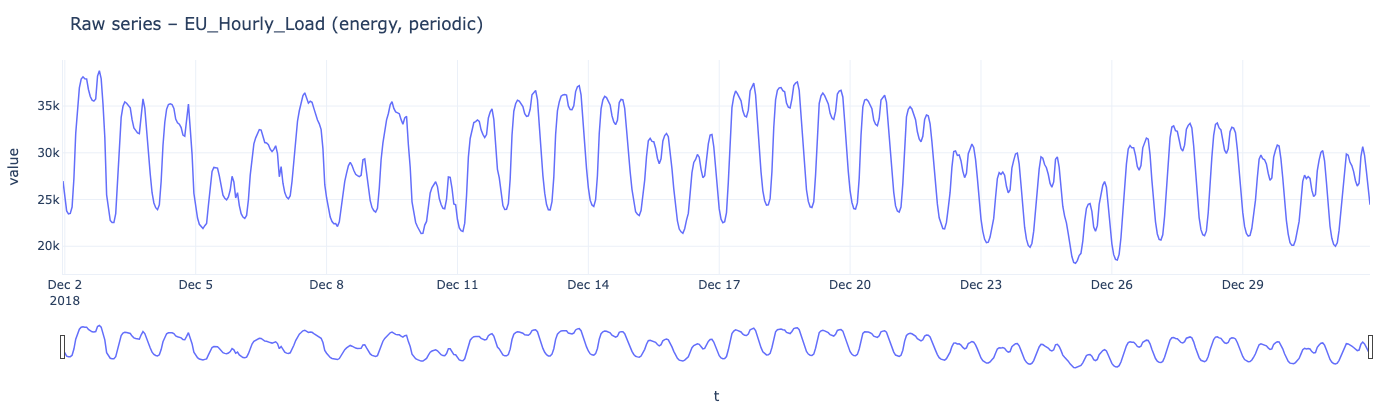

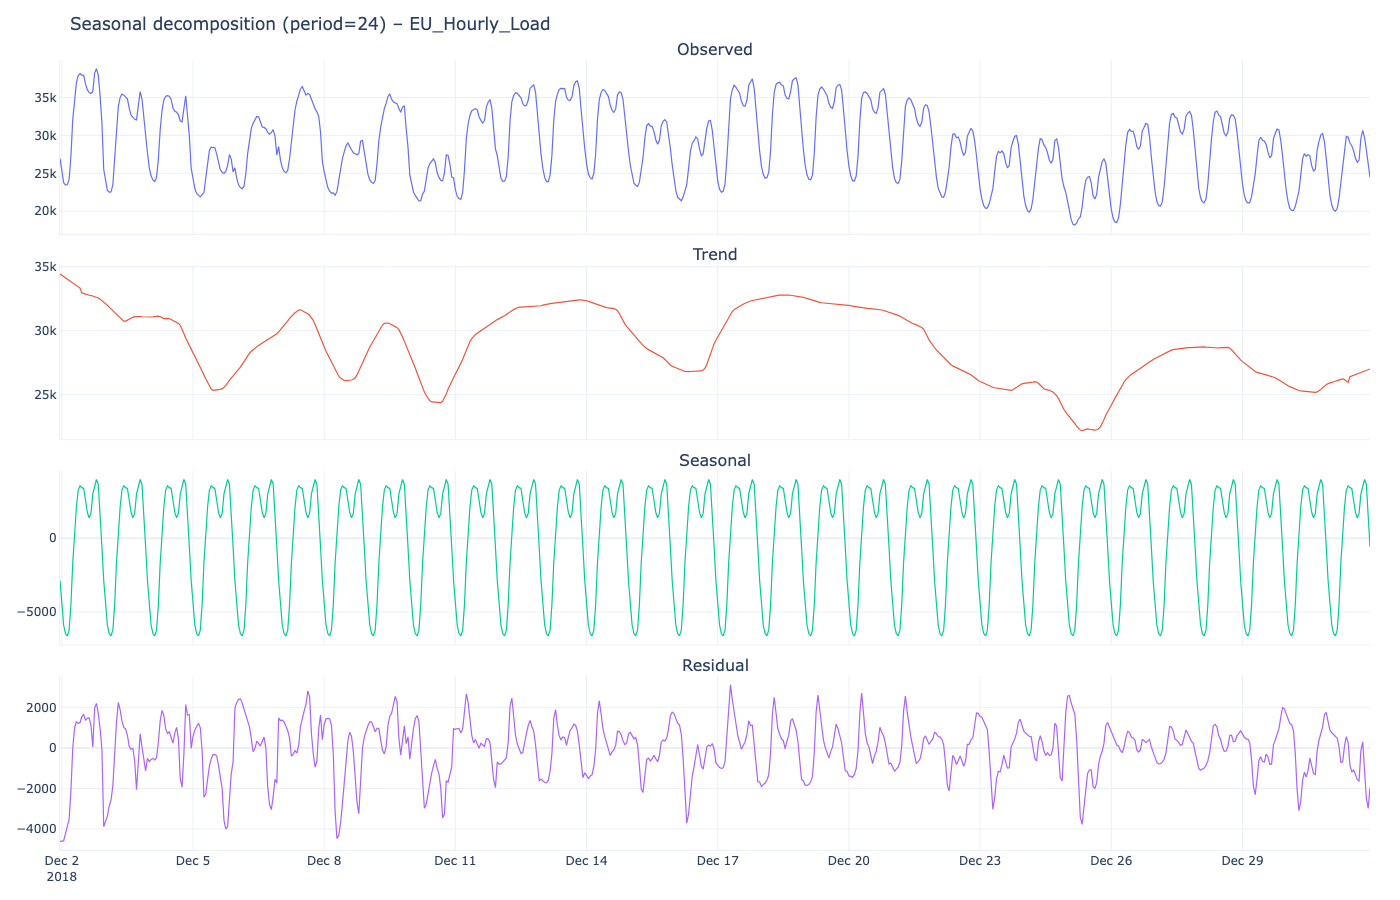

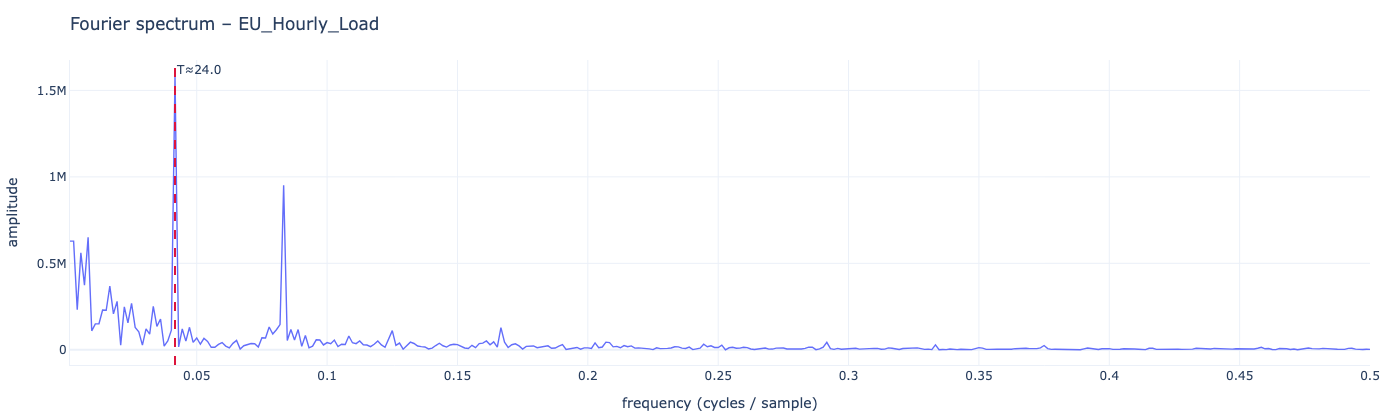

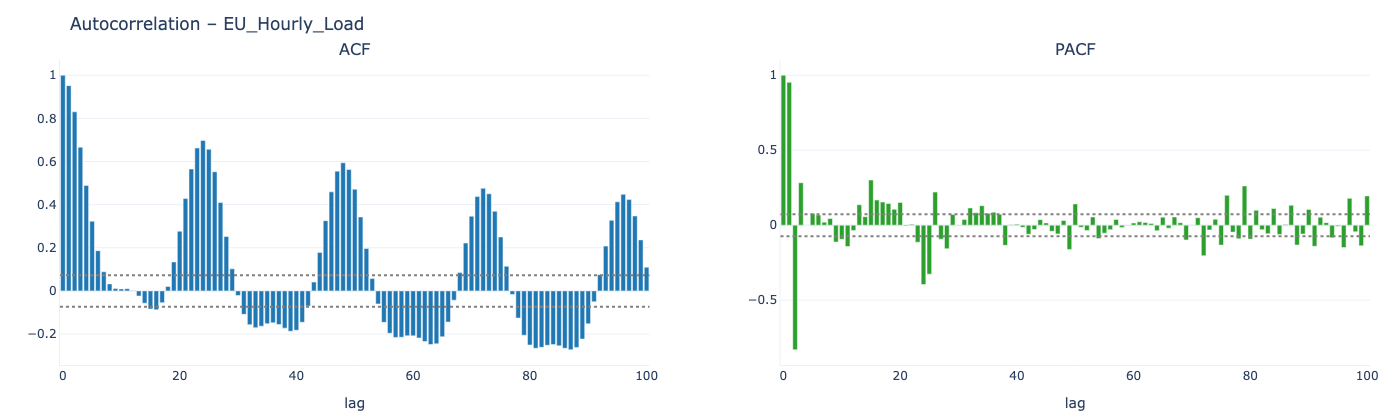

done: EU_Hourly_Load | H=0.967 λ=0.0668 PE=0.723


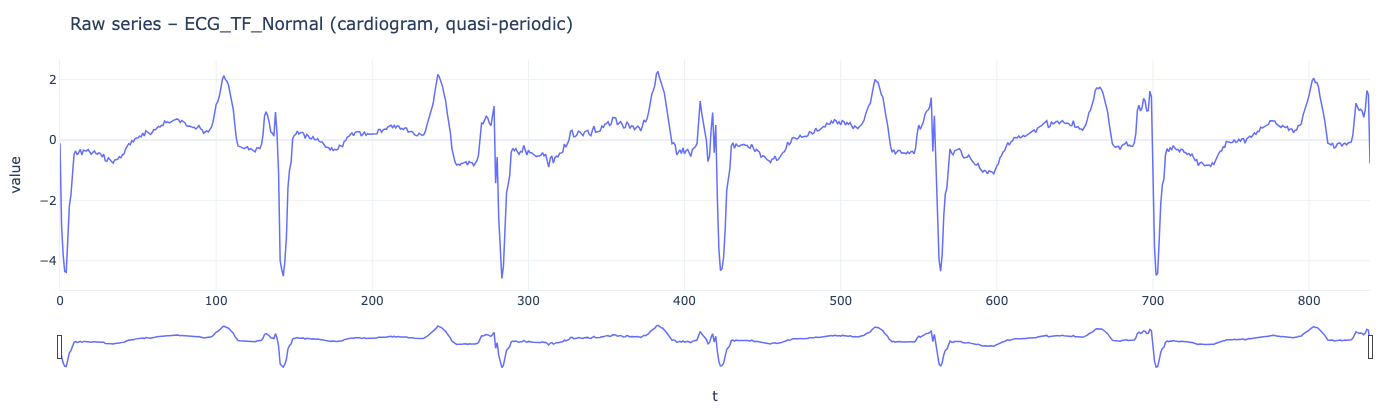

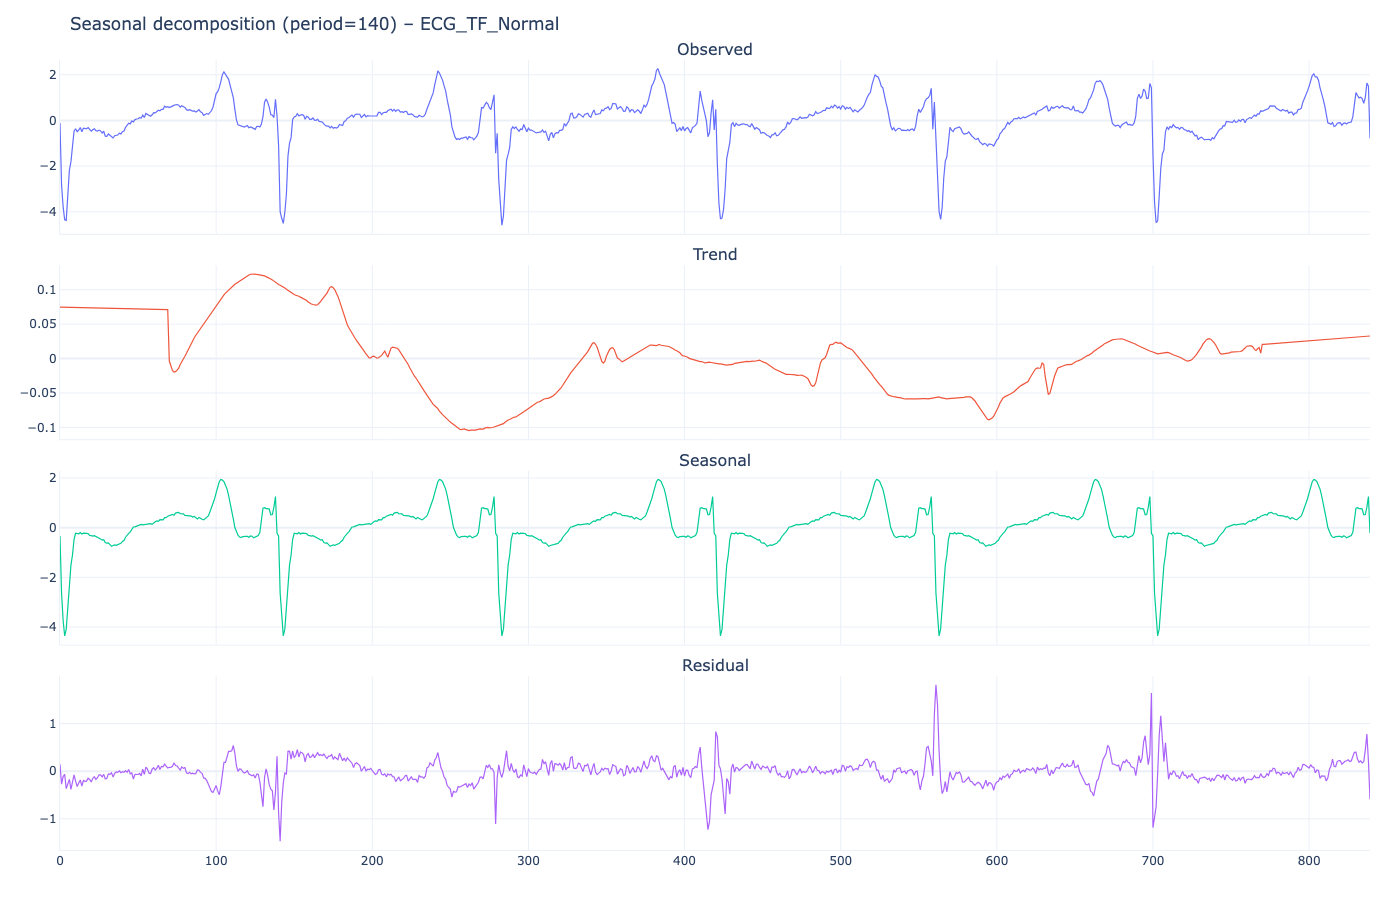

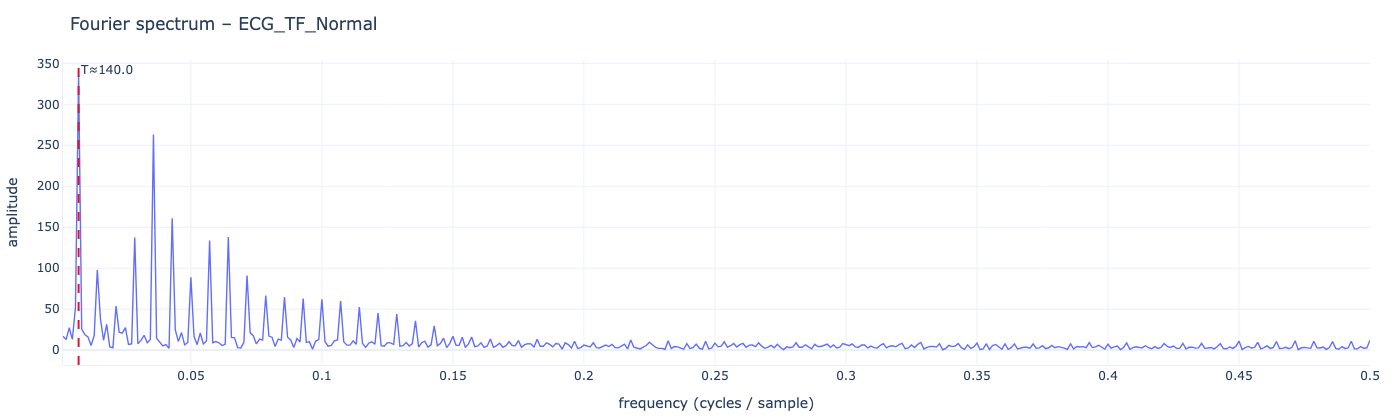

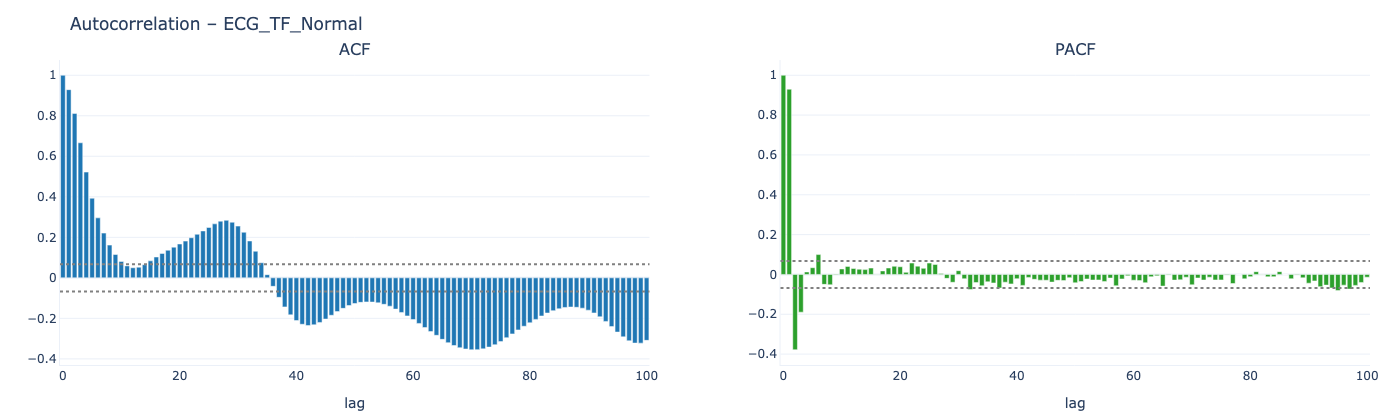

done: ECG_TF_Normal | H=0.815 λ=0.0667 PE=0.941


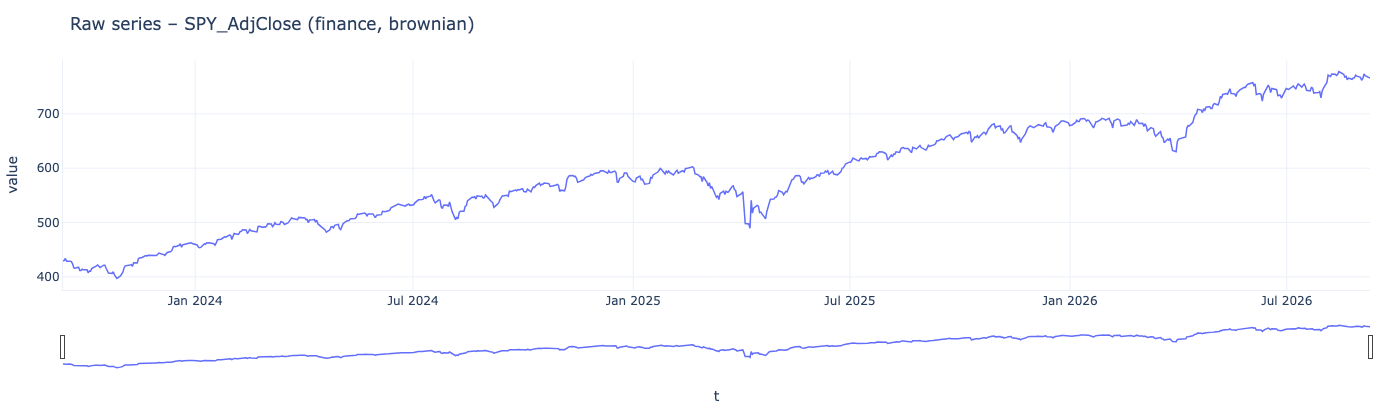

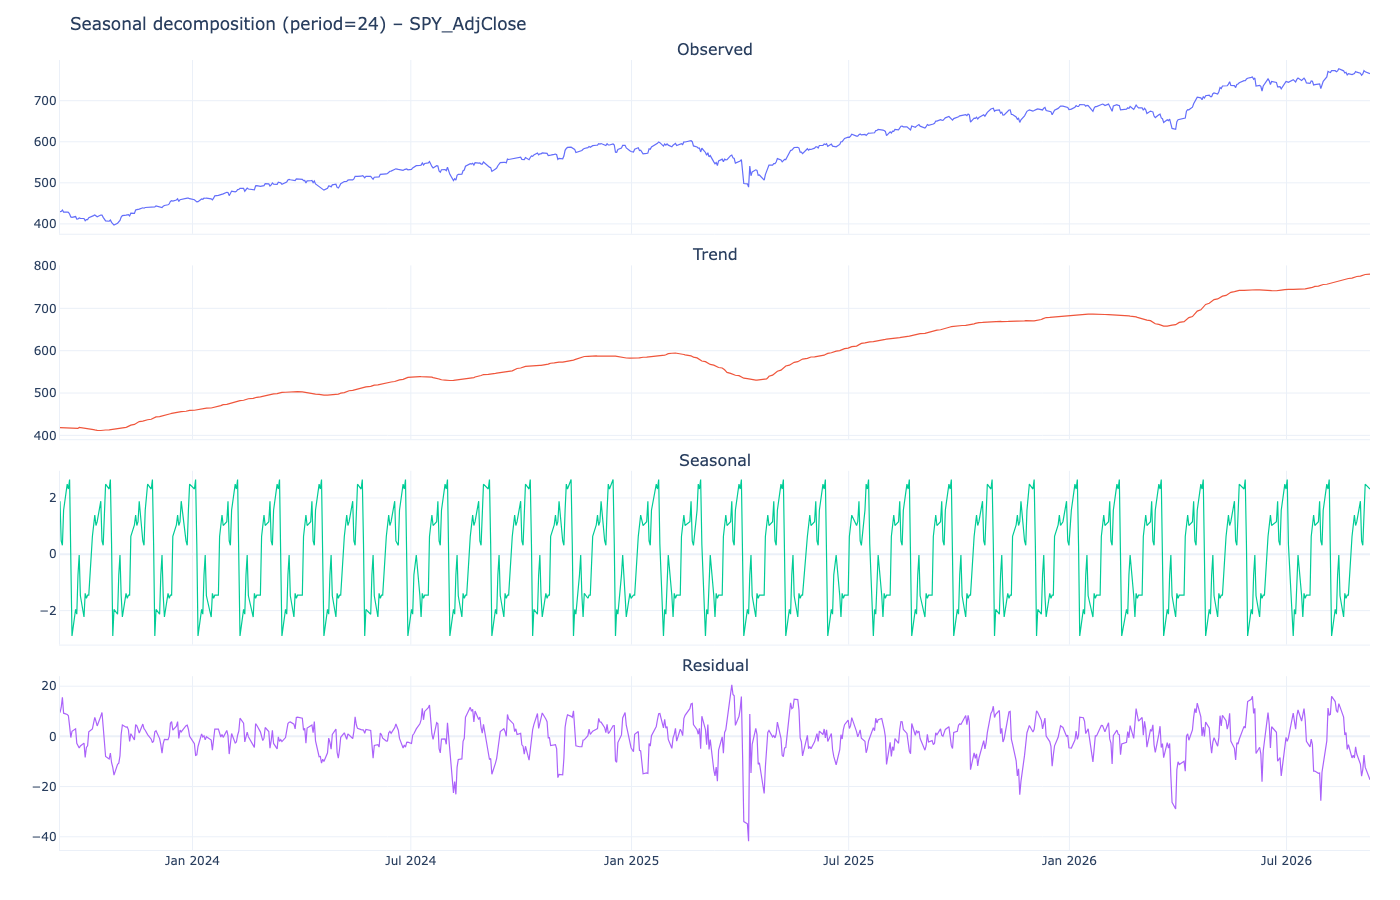

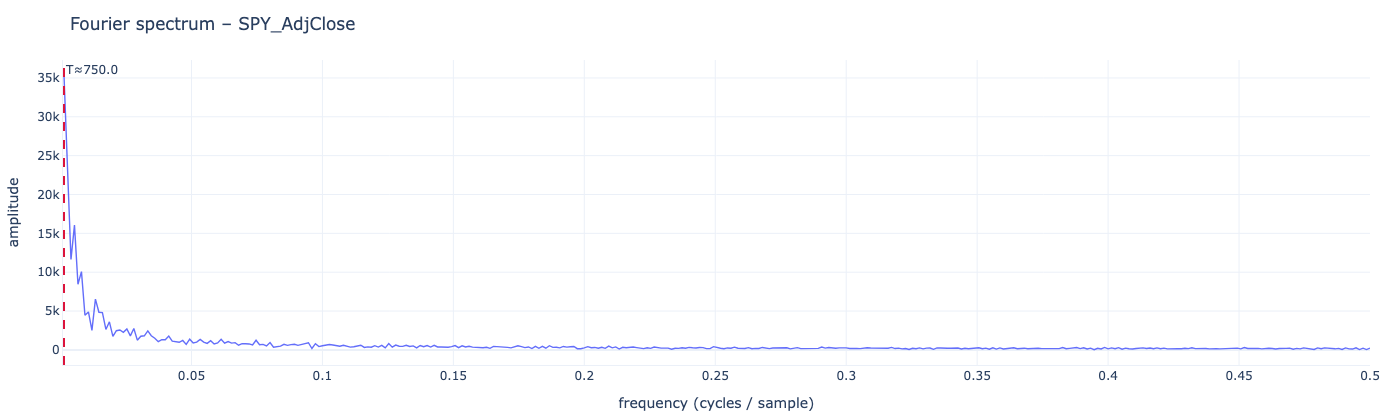

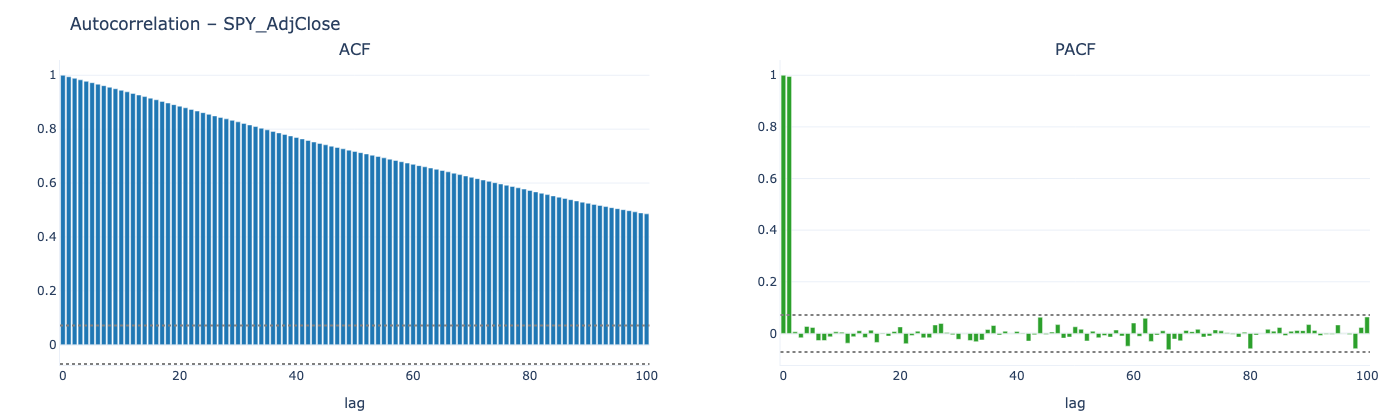

done: SPY_AdjClose | H=0.902 λ=0.0635 PE=0.948


3

In [15]:
RESULTS: List[AnalysisResult] = []
ARTIFACTS: Dict[str, List[Path]] = {}

for bundle in SERIES:
    result = analyze_series(bundle)
    RESULTS.append(result)

    paths = [
        show_and_save(plot_raw_series(result), f"{result.name}_raw", height=420),
        show_and_save(plot_decomposition(result), f"{result.name}_decomp", height=900),
        show_and_save(plot_fft(result), f"{result.name}_fft", height=420),
        show_and_save(plot_acf_pacf(result), f"{result.name}_acf", height=420),
    ]
    ARTIFACTS[result.name] = paths
    print(f"done: {result.name} | H={result.hurst:.3f} λ={result.lyapunov:.4f} PE={result.perm_entropy:.3f}")

len(RESULTS)


## 5. Summary table & predictability



### Why these interpretation thresholds?

Banded labels below are **heuristics for reading the diagnostics**, not hard physical laws. They follow common usage in the Hurst / Lyapunov / Bandt–Pompe literature and are tuned so the three series in this lab separate in a sensible way.

#### Hurst $H$ (`interpret_hurst`)

| Band | Label | Argument |
|---|---|---|
| $H < 0.45$ | anti-persistent | Classical R/S reading: $H<0.5$ mean-reverting / negatively correlated increments (Hurst 1951; Mandelbrot & Wallis). $0.45$ leaves a small buffer so noise around $0.5$ is not over-called. |
| $\|H-0.5\| < 0.08$ | near random-walk | Uncorrelated increments $\Rightarrow H\approx 0.5$. The $\pm 0.08$ window absorbs finite-sample bias of R/S on $N\sim 500$–$1000$ (nolds / typical lab noise). |
| $H > 0.6$ | persistent | Clear long-memory / trend-following regime; $0.6$ is a common “clearly above $0.5$” cutoff used in applied TS notes. |
| else | weakly persistent | Between the RW band and $0.6$: mild memory, not decisive. |

Hausdorff label uses the identity $D_H=2-H$ for a self-affine graph (no extra threshold).

#### Largest Lyapunov $\lambda_1$ (`interpret_lyapunov`)

| Band | Label | Argument |
|---|---|---|
| $\lambda_1 \le 0$ | non-chaotic / stable | By definition, $\lambda_1\le 0$ $\Rightarrow$ no exponential divergence of nearby trajectories. |
| $\lambda_1 > 0.05$ | sensitive dependence | Strictly, any $\lambda_1>0$ is chaotic in the Pesin sense; $0.05$ filters tiny positive estimates from embedding noise / short series (Rosenstein / `nolds.lyap_r` on $N\sim 10^3$). |
| else $(0,\ 0.05]$ | mildly unstable | Positive but small: possible weak chaos or estimation artifact – flag without overstating. |

KS entropy uses Pesin in 1D: $h_{\mathrm{KS}}\approx\max(\lambda_1,0)$ (same sign information as $\lambda_1$).

#### Permutation entropy $H_{\mathrm{PE}}^{\mathrm{norm}}$ (`interpret_pe`)

Normalized Bandt–Pompe PE lies in $[0,1]$; $m=3$ $\Rightarrow$ at most $3!=6$ patterns.

| Band | Label | Argument |
|---|---|---|
| PE $< 0.7$ | structured ordinal | Clear concentration on few ordinal patterns (periodic / strongly constrained signals – e.g. load, clean ECG morphology). |
| PE $> 0.85$ | near-random ordinal | Close to uniform over $\pi$; little short-term ordinal structure (typical of noisy / martingale-like series). |
| else | mixed structure | Intermediate complexity – common for quasi-periodic ECG with HRV. |

Cutoffs $0.7$ / $0.85$ are practical reading bands for **normalized** PE (raw $H_{\mathrm{PE}}$ would need different numbers).

#### Predictability score (`predictability_score`)

Lower score $\Rightarrow$ **more** forecastable under these diagnostics:

| Rule | $\Delta$ score | Argument |
|---|---|---|
| $\|H-0.5\|<0.08$ | $+1$ | Near-RW increments $\Rightarrow$ weak linear predictability of the level. |
| $H>0.6$ | $-1$ | Persistence / trend memory can help short-horizon level forecasts (esp. load). |
| $\lambda_1>0.05$ | $+1$ | Sensitive dependence $\Rightarrow$ horizon collapses; long forecasts unreliable. |
| PE $>0.85$ | $+1$ | Ordinal patterns near noise $\Rightarrow$ little deterministic short-term structure. |
| PE $<0.7$ | $-1$ | Structured ordinal dynamics $\Rightarrow$ more short-term regularity. |
| $2 < T_{\mathrm{FFT}} < N/3$ | $-1$ | Usable seasonal / cyclic peak (not DC, not longer than a third of the sample). |

Label map: score $\ge 2$ → `low`; $\le -1$ → `higher`; else `moderate`.

**Caveat:** SPY can show high $H$ on the **price level** (persistent trend) while returns remain hard to forecast – that is why PE / FFT / Lyapunov are combined with $H$, not $H$ alone.

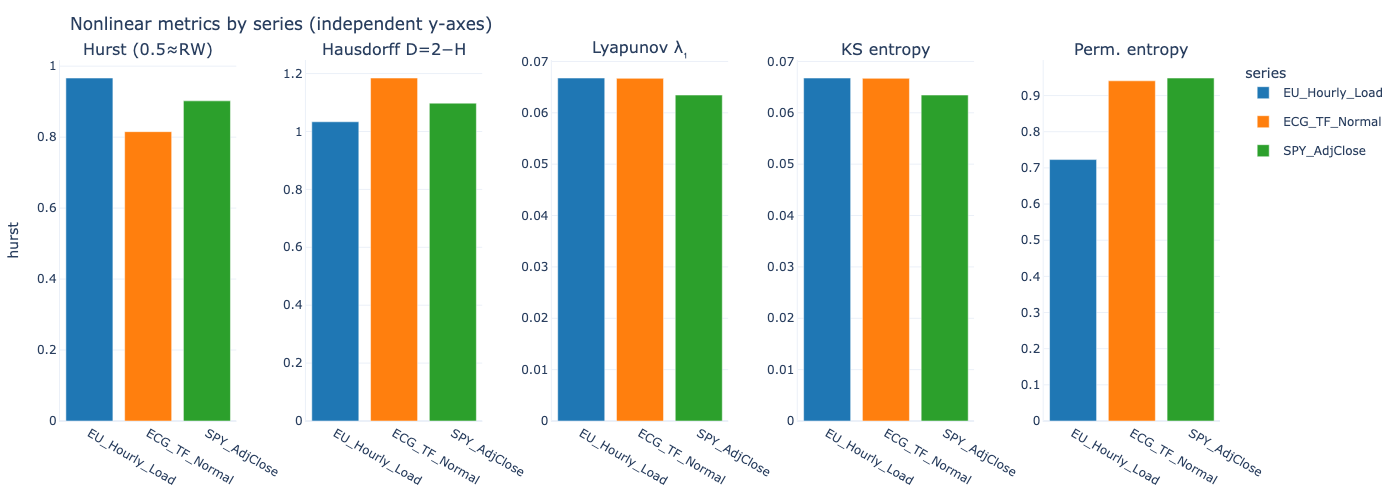

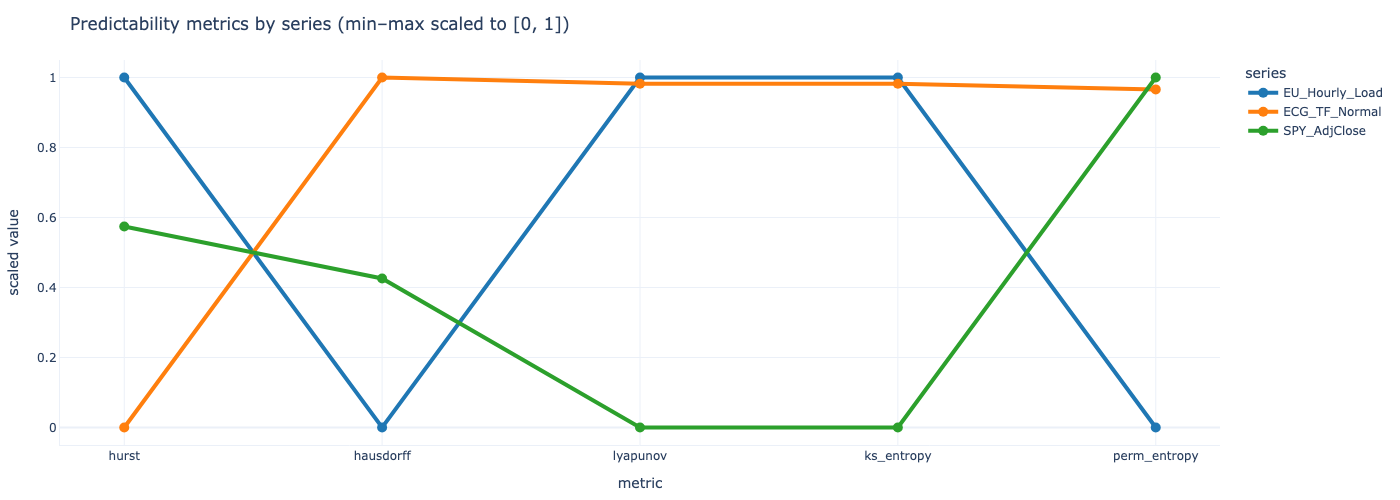

PosixPath('/Users/lopatenko/Desktop/itmo/itmo-ml-2025/tsml/lab-1/figures/metrics_parallel.png')

In [16]:
def interpret_hurst(h: float) -> str:
    if h < 0.45:
        return "anti-persistent"
    if abs(h - 0.5) < 0.08:
        return "near random-walk"
    if h > 0.6:
        return "persistent"
    return "weakly persistent"


def interpret_lyapunov(lam: float) -> str:
    if lam <= 0:
        return "non-chaotic / stable"
    if lam > 0.05:
        return "sensitive dependence"
    return "mildly unstable"


def interpret_pe(pe: float) -> str:
    if pe < 0.7:
        return "structured ordinal"
    if pe > 0.85:
        return "near-random ordinal"
    return "mixed structure"


def predictability_score(row: pd.Series) -> int:
    # lower score => more predictable
    score = 0
    if abs(row["hurst"] - 0.5) < 0.08:
        score += 1
    if row["hurst"] > 0.6:
        score -= 1
    if row["lyapunov"] > 0.05:
        score += 1
    if row["perm_entropy"] > 0.85:
        score += 1
    if row["perm_entropy"] < 0.7:
        score -= 1
    # clear seasonal FFT peak relative to length helps predictability
    T = row["dominant_period_fft"]
    if np.isfinite(T) and 2 < T < row["n"] / 3:
        score -= 1
    return int(score)


def predictability_label(score: int) -> str:
    if score >= 2:
        return "low"
    if score <= -1:
        return "higher"
    return "moderate"


def interpret_row(row: pd.Series) -> Dict[str, str]:
    h_read = interpret_hurst(float(row["hurst"]))
    lyap_read = interpret_lyapunov(float(row["lyapunov"]))
    pe_read = interpret_pe(float(row["perm_entropy"]))
    score = predictability_score(row)

    return {
        "hurst_read": h_read,
        "hausdorff_read": f"D=2−H≈{2.0 - float(row['hurst']):.3f}",
        "lyap_read": lyap_read,
        "pe_read": pe_read,
        "predictability": predictability_label(score),
        "pred_score": score,
    }


summary = pd.DataFrame(
    [
        {
            "name": r.name,
            "domain": r.domain,
            "kind": r.kind,
            "n": r.n,
            "seasonal_period": r.period,
            "dominant_period_fft": r.dominant_period_fft,
            "hurst": r.hurst,
            "hausdorff": r.hausdorff,
            "lyapunov": r.lyapunov,
            "ks_entropy": r.ks_entropy,
            "perm_entropy": r.perm_entropy,
        }
        for r in RESULTS
    ]
)

interp = summary.apply(interpret_row, axis=1, result_type="expand")
summary = pd.concat([summary, interp], axis=1)

show_and_save(plot_metrics_comparison(summary), "metrics_comparison", height=500)
show_and_save(plot_parallel_coords(summary), "metrics_parallel", height=500)

In [17]:
summary

,name,domain,kind,n,seasonal_period,dominant_period_fft,hurst,hausdorff,lyapunov,ks_entropy,perm_entropy,hurst_read,hausdorff_read,lyap_read,pe_read,predictability,pred_score
0,EU_Hourly_Load,energy,periodic,720,24,24.0,0.966525,1.033475,0.066766,0.066766,0.722939,persistent,D=2−H≈1.033,sensitive dependence,mixed structure,higher,-1
1,ECG_TF_Normal,cardiogram,quasi-periodic,840,140,140.0,0.815430,1.184570,0.066707,0.066707,0.940778,persistent,D=2−H≈1.185,sensitive dependence,near-random ordinal,moderate,0
2,SPY_AdjClose,finance,brownian,750,24,750.0,0.902201,1.097799,0.063453,0.063453,0.948442,persistent,D=2−H≈1.098,sensitive dependence,near-random ordinal,moderate,1


## 6. Preliminary conclusion


In [18]:
def build_conclusion(summary: pd.DataFrame) -> str:
    ranked = summary.sort_values("pred_score")
    best = ranked.iloc[0]
    worst = ranked.iloc[-1]
    lowest_pe = summary.loc[summary["perm_entropy"].idxmin()]
    clearest_fft = summary.loc[
        summary["dominant_period_fft"].apply(
            lambda T: abs(T - round(T)) if np.isfinite(T) and 2 < T < 1e6 else 1e9
        ).idxmin()
    ]

    lines = [
        "Observed diagnostics (auto-filled from summary):",
        "",
    ]
    for _, row in summary.iterrows():
        lines.append(
            f"- **{row['name']}**: H={row['hurst']:.3f} ({row['hurst_read']}), "
            f"λ={row['lyapunov']:.4f} ({row['lyap_read']}), "
            f"PE={row['perm_entropy']:.3f} ({row['pe_read']}), "
            f"FFT≈{row['dominant_period_fft']:.1f}, predictability={row['predictability']}"
        )

    lines.extend(
        [
            "",
            f"Most forecastable under these heuristics: **{best['name']}** "
            f"(score={int(best['pred_score'])}, {best['predictability']}).",
            f"Least forecastable: **{worst['name']}** "
            f"(score={int(worst['pred_score'])}, {worst['predictability']}).",
            f"Lowest permutation entropy (most ordinal structure): **{lowest_pe['name']}** "
            f"(PE={lowest_pe['perm_entropy']:.3f}).",
            f"Clearest near-integer FFT period: **{clearest_fft['name']}** "
            f"(T≈{clearest_fft['dominant_period_fft']:.1f}).",
            "",
            "This matches the domain priors: electricity load carries calendar cycles; "
            "ECG retains beat morphology; equity levels remain closer to a hard-to-forecast walk "
            "despite a high Hurst on the raw price path (trend persistence ≠ easy return forecast).",
        ]
    )
    return "\n".join(lines)


CONCLUSION_MD = build_conclusion(summary)

from IPython.display import Markdown, display
display(Markdown(CONCLUSION_MD))


Observed diagnostics (auto-filled from summary):

- **EU_Hourly_Load**: H=0.967 (persistent), λ=0.0668 (sensitive dependence), PE=0.723 (mixed structure), FFT≈24.0, predictability=higher
- **ECG_TF_Normal**: H=0.815 (persistent), λ=0.0667 (sensitive dependence), PE=0.941 (near-random ordinal), FFT≈140.0, predictability=moderate
- **SPY_AdjClose**: H=0.902 (persistent), λ=0.0635 (sensitive dependence), PE=0.948 (near-random ordinal), FFT≈750.0, predictability=moderate

Most forecastable under these heuristics: **EU_Hourly_Load** (score=-1, higher).
Least forecastable: **SPY_AdjClose** (score=1, moderate).
Lowest permutation entropy (most ordinal structure): **EU_Hourly_Load** (PE=0.723).
Clearest near-integer FFT period: **ECG_TF_Normal** (T≈140.0).

This matches the domain priors: electricity load carries calendar cycles; ECG retains beat morphology; equity levels remain closer to a hard-to-forecast walk despite a high Hurst on the raw price path (trend persistence ≠ easy return forecast).